In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving traffic.xlsx to traffic.xlsx


In [ ]:
df_copy.head()

,Clicks,Impressions,Position,BounceRate,ViewDepth,TimeSpent,RobotsVisits,Mobility,Segments,Title Length,Meta Description Length,H1 Length,Word Count,Sentence Count,Folder Depth,Link Score,Inlinks,Outlinks,Response Time
0,1939,41950,8.6,0.099963,2.657336,0 days 00:11:30,837.0,0.271619,Unknown,83.0,188.0,0.0,1553.0,367.0,0.0,99.0,24095.0,334.0,2.185
1,1798,27042,8.2,0.314512,1.154715,0 days 00:00:41,7.0,0.869001,product,152.0,227.0,37.0,950.0,377.0,3.0,2.0,173.0,77.0,1.332
2,951,18076,6.3,0.338804,1.259086,0 days 00:00:53,3.0,0.852286,product,101.0,159.0,38.0,858.0,341.0,3.0,1.0,143.0,77.0,1.759
3,863,10697,7.9,0.262894,1.348854,0 days 00:00:43,3.0,0.829513,product,70.0,137.0,24.0,910.0,359.0,3.0,1.0,143.0,77.0,1.495
4,822,7269,17.8,0.221176,3.207843,0 days 00:02:19,27.0,0.534118,Unknown,85.0,181.0,24.0,528.0,103.0,2.0,2.0,120.0,334.0,0.180


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9439 entries, 0 to 9438
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Clicks                   9439 non-null   int64          
 1   Impressions              9439 non-null   int64          
 2   Position                 9439 non-null   float64        
 3   BounceRate               9439 non-null   float64        
 4   ViewDepth                9439 non-null   float64        
 5   TimeSpent                9439 non-null   timedelta64[ns]
 6   RobotsVisits             9439 non-null   float64        
 7   Mobility                 9439 non-null   float64        
 8   Segments                 9439 non-null   object         
 9   Title Length             9439 non-null   float64        
 10  Meta Description Length  9439 non-null   float64        
 11  H1 Length                9439 non-null   float64        
 12  Word Count          

In [ ]:
df_copy.shape

(9439, 19)

In [ ]:
df_copy.columns

Index(['Clicks', 'Impressions', 'Position', 'BounceRate', 'ViewDepth',
       'TimeSpent', 'RobotsVisits', 'Mobility', 'Segments', 'Title Length',
       'Meta Description Length', 'H1 Length', 'Word Count', 'Sentence Count',
       'Folder Depth', 'Link Score', 'Inlinks', 'Outlinks', 'Response Time'],
      dtype='object')

In [ ]:
df_copy.dtypes

,0
Clicks,int64
Impressions,int64
Position,float64
BounceRate,float64
ViewDepth,float64
TimeSpent,object
RobotsVisits,float64
Mobility,float64
Segments,object
Title Length,float64


In [ ]:
df_copy.isnull().sum()

,0
Clicks,0
Impressions,0
Position,0
BounceRate,7790
ViewDepth,7790
TimeSpent,7790
RobotsVisits,7790
Mobility,7790
Segments,414
Title Length,237


In [ ]:
(df_copy.isnull().sum()/len(df_copy))*100

,0
Clicks,0.000000
Impressions,0.000000
Position,0.000000
BounceRate,82.529929
ViewDepth,82.529929
TimeSpent,82.529929
RobotsVisits,82.529929
Mobility,82.529929
Segments,4.386058
Title Length,2.510859


In [ ]:
df_copy.duplicated().sum()

np.int64(0)

In [ ]:
df_copy = df_copy.drop_duplicates()

In [ ]:
df_copy.select_dtypes(include="number").columns

Index(['Clicks', 'Impressions', 'Position', 'BounceRate', 'ViewDepth',
       'RobotsVisits', 'Mobility', 'Title Length', 'Meta Description Length',
       'H1 Length', 'Word Count', 'Sentence Count', 'Folder Depth',
       'Link Score', 'Inlinks', 'Outlinks', 'Response Time'],
      dtype='object')

In [ ]:
numeric_cols = df_copy.select_dtypes(include="number").columns

df_copy[numeric_cols] = df_copy[numeric_cols].fillna(df_copy[numeric_cols].mean())

In [ ]:
df_copy["Segments"] = df_copy["Segments"].fillna("Unknown")

In [ ]:
df_copy.isnull().sum()

,0
Clicks,0
Impressions,0
Position,0
BounceRate,0
ViewDepth,0
TimeSpent,7790
RobotsVisits,0
Mobility,0
Segments,0
Title Length,0


In [ ]:
df_copy["TimeSpent"] = pd.to_timedelta(df_copy["TimeSpent"])

In [ ]:
average_time = df_copy["TimeSpent"].mean()

df_copy["TimeSpent"] = df_copy["TimeSpent"].fillna(average_time)

In [ ]:
df_copy.isnull().sum()

,0
Clicks,0
Impressions,0
Position,0
BounceRate,0
ViewDepth,0
TimeSpent,0
RobotsVisits,0
Mobility,0
Segments,0
Title Length,0


In [ ]:
df.to_excel("traffic.xlsx", index=False)

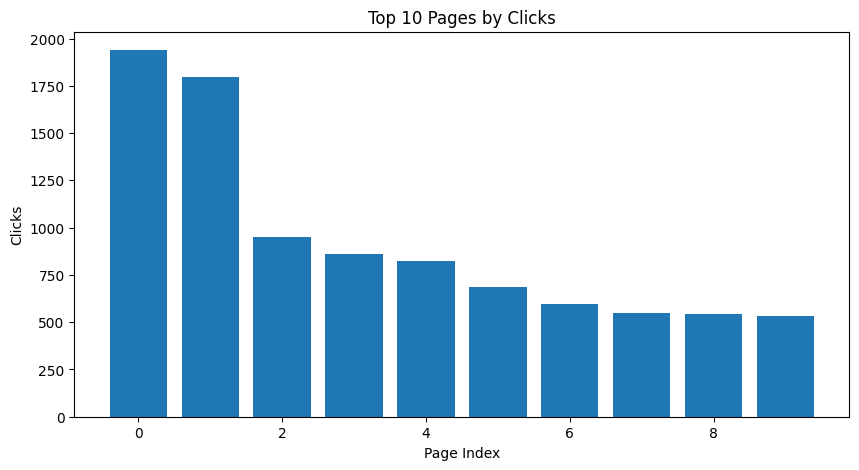

In [ ]:
top10 = df_copy.nlargest(10, "Clicks")

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10["Clicks"])

plt.title("Top 10 Pages by Clicks")
plt.xlabel("Page Index")
plt.ylabel("Clicks")

plt.show()

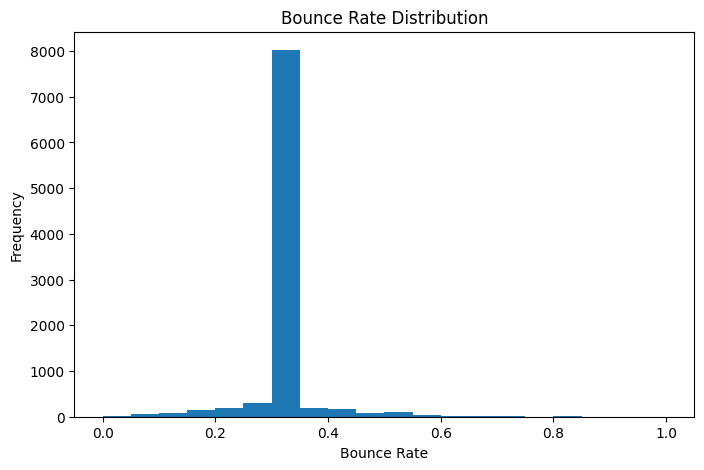

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df_copy["BounceRate"], bins=20)

plt.title("Bounce Rate Distribution")
plt.xlabel("Bounce Rate")
plt.ylabel("Frequency")

plt.show()

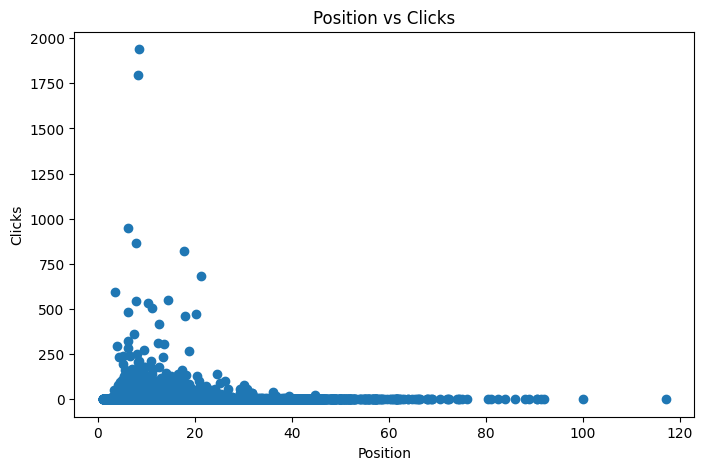

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df_copy["Position"], df_copy["Clicks"])

plt.title("Position vs Clicks")
plt.xlabel("Position")
plt.ylabel("Clicks")

plt.show()

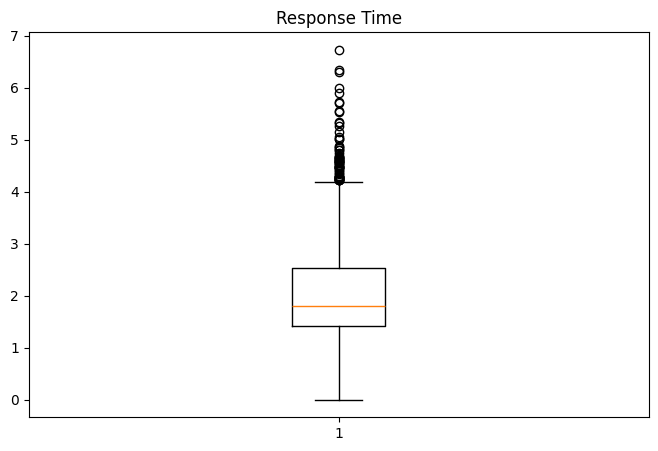

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df_copy["Response Time"])

plt.title("Response Time")

plt.show()

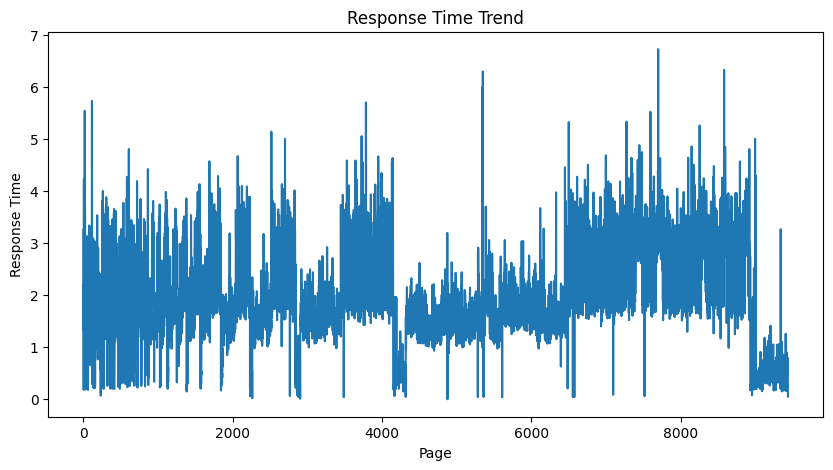

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df_copy["Response Time"])

plt.title("Response Time Trend")
plt.xlabel("Page")
plt.ylabel("Response Time")

plt.show()

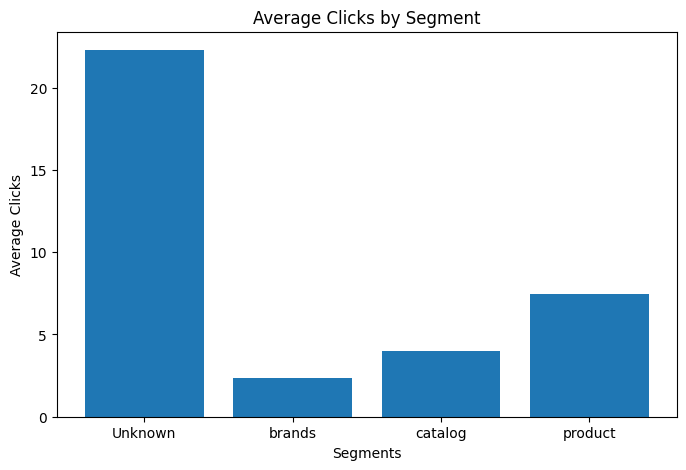

In [ ]:
avg_clicks = df_copy.groupby("Segments")["Clicks"].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_clicks.index, avg_clicks.values)

plt.title("Average Clicks by Segment")
plt.xlabel("Segments")
plt.ylabel("Average Clicks")

plt.show()